<a href="https://colab.research.google.com/github/kagabrielco-netizen/Laboratorio_UCV_NLP_Sentimientos_UCI_MLP/blob/main/Laboratorio_UCV_NLP_Sentimientos_UCI_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD CÉSAR VALLEJO
## Escuela Profesional de Ingeniería de Sistemas

# LABORATORIO COMPLETO
## Análisis de sentimientos usando NLP clásico y Perceptrón Multicapa

**Curso:** Sistemas Inteligentes  
**Unidad:** Tercera unidad  
**Tema:** NLP clásico y redes neuronales  
**Duración sugerida:** 1 sesión de laboratorio + trabajo autónomo  
**Herramientas:** Python, Jupyter Notebook, Pandas, Scikit-Learn, Matplotlib y UCI Machine Learning Repository  
**Producto final:** Modelo capaz de clasificar comentarios como positivos o negativos.


## 1. Presentación del laboratorio

En este laboratorio el estudiante construirá un sistema básico de **análisis de sentimientos** utilizando técnicas de NLP clásico y un **Perceptrón Multicapa (MLP)**.

El objetivo es comprender cómo una computadora puede transformar texto en números y luego aprender patrones para clasificar opiniones como positivas o negativas.

Este laboratorio sirve como puente hacia la siguiente sesión de **Transformers, LLM y RAG**, porque primero se estudiará una forma clásica de trabajar con texto antes de pasar a modelos modernos de lenguaje.


## 2. Resultado de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

- Cargar un dataset real de sentimientos.
- Limpiar comentarios de texto.
- Convertir texto en vectores mediante TF-IDF.
- Entrenar un modelo MLP para clasificación binaria.
- Evaluar el modelo con accuracy, precision, recall y F1-score.
- Analizar errores del modelo.
- Explicar las limitaciones del NLP clásico frente a modelos basados en Transformers.


## 3. Contexto del caso

Una empresa desea monitorear automáticamente la reputación de sus productos y servicios. Cada día recibe cientos o miles de comentarios de clientes en plataformas como Amazon, Yelp o IMDb.

El objetivo es construir un sistema que clasifique cada comentario como:

```text
0 = Negativo
1 = Positivo
```

Esto permitiría priorizar reclamos, medir satisfacción y detectar problemas de servicio.


## 4. Dataset utilizado

Se utilizará el dataset **Sentiment Labelled Sentences** del UCI Machine Learning Repository.

El conjunto contiene opiniones etiquetadas provenientes de:

- Amazon
- Yelp
- IMDb

Cada frase tiene una etiqueta:

- `0`: sentimiento negativo.
- `1`: sentimiento positivo.

Para evitar problemas de conexión o cambios en la estructura de descarga, este notebook intentará cargar el dataset desde UCI. Si no se encuentra disponible, utilizará un dataset pequeño incorporado como respaldo académico.


## 5. Arquitectura conceptual

El flujo del laboratorio será:

```text
Comentario de cliente
      ↓
Limpieza de texto
      ↓
TF-IDF
      ↓
Perceptrón Multicapa
      ↓
Sentimiento positivo o negativo
```


## 6. Preparación del entorno

Ejecute esta celda si trabaja en Google Colab o en un entorno local sin las librerías instaladas.


In [24]:
%pip install pandas numpy matplotlib scikit-learn requests -q

## 7. Importar librerías


In [25]:
import re
import zipfile
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

np.random.seed(42)

## 8. Cargar dataset desde UCI

El dataset original puede descargarse desde UCI como archivo ZIP. El notebook intentará descargarlo automáticamente.


In [26]:
def load_uci_sentiment_dataset():
    url = 'https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip'
    zip_path = Path('sentiment_labelled_sentences.zip')
    extract_dir = Path('sentiment_labelled_sentences')

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    possible_files = [
        extract_dir / 'sentiment labelled sentences' / 'amazon_cells_labelled.txt',
        extract_dir / 'sentiment labelled sentences' / 'imdb_labelled.txt',
        extract_dir / 'sentiment labelled sentences' / 'yelp_labelled.txt',
    ]

    frames = []

    for file_path in possible_files:
        if file_path.exists():
            temp_df = pd.read_csv(
                file_path,
                sep='\t',
                header=None,
                names=['text', 'sentiment'],
            )
            temp_df['source'] = file_path.stem.replace('_labelled', '')
            frames.append(temp_df)

    if not frames:
        raise FileNotFoundError('No se encontraron archivos del dataset UCI.')

    return pd.concat(frames, ignore_index=True)


def load_fallback_dataset():
    examples = [
        ('I love this product', 1, 'fallback'),
        ('This is an excellent service', 1, 'fallback'),
        ('The movie was amazing', 1, 'fallback'),
        ('The food was delicious', 1, 'fallback'),
        ('I am very happy with the purchase', 1, 'fallback'),
        ('The staff was friendly', 1, 'fallback'),
        ('This phone works perfectly', 1, 'fallback'),
        ('The experience was wonderful', 1, 'fallback'),
        ('I would buy it again', 1, 'fallback'),
        ('Highly recommended', 1, 'fallback'),
        ('I hate this product', 0, 'fallback'),
        ('This is a terrible service', 0, 'fallback'),
        ('The movie was boring', 0, 'fallback'),
        ('The food was awful', 0, 'fallback'),
        ('I am very disappointed', 0, 'fallback'),
        ('The staff was rude', 0, 'fallback'),
        ('This phone does not work', 0, 'fallback'),
        ('The experience was horrible', 0, 'fallback'),
        ('I would never buy it again', 0, 'fallback'),
        ('Not recommended', 0, 'fallback'),
    ]
    return pd.DataFrame(examples, columns=['text', 'sentiment', 'source'])


try:
    df = load_uci_sentiment_dataset()
    print('Dataset UCI cargado correctamente.')
except Exception as error:
    print('No se pudo cargar UCI. Se usará dataset de respaldo.')
    print('Detalle:', error)
    df = load_fallback_dataset()

df.head()

Dataset UCI cargado correctamente.


,text,sentiment,source
0,So there is no way for me to plug it in here i...,0,amazon_cells
1,"Good case, Excellent value.",1,amazon_cells
2,Great for the jawbone.,1,amazon_cells
3,Tied to charger for conversations lasting more...,0,amazon_cells
4,The mic is great.,1,amazon_cells


## 9. Exploración inicial


In [27]:
print('Dimensión del dataset:', df.shape)
df.info()

Dimensión del dataset: (2748, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       2748 non-null   object
 1   sentiment  2748 non-null   int64 
 2   source     2748 non-null   object
dtypes: int64(1), object(2)
memory usage: 64.5+ KB


In [28]:
df['sentiment'].value_counts().sort_index()

,count
sentiment,
0,1362
1,1386


In [29]:
df['source'].value_counts()

,count
source,
amazon_cells,1000
yelp,1000
imdb,748


## 10. Visualizar distribución de clases


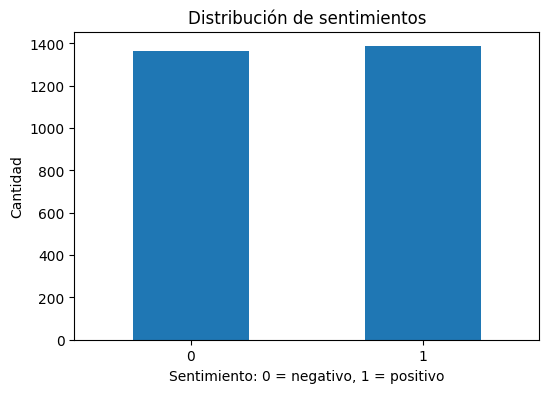

In [30]:
df['sentiment'].value_counts().sort_index().plot(kind='bar', figsize=(6, 4))
plt.title('Distribución de sentimientos')
plt.xlabel('Sentimiento: 0 = negativo, 1 = positivo')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

## 11. Limpieza de texto

La limpieza básica incluye:

- Convertir a minúsculas.
- Eliminar caracteres especiales.
- Quitar espacios duplicados.

No se hará una limpieza agresiva porque algunas palabras son importantes para detectar sentimiento.


In [31]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text', 'sentiment']].head(10)

,text,clean_text,sentiment
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",good case excellent value,1
2,Great for the jawbone.,great for the jawbone,1
3,Tied to charger for conversations lasting more...,tied to charger for conversations lasting more...,0
4,The mic is great.,the mic is great,1
5,I have to jiggle the plug to get it to line up...,i have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,if you have several dozen or several hundred c...,0
7,If you are Razr owner...you must have this!,if you are razr owner you must have this,1
8,"Needless to say, I wasted my money.",needless to say i wasted my money,0
9,What a waste of money and time!.,what a waste of money and time,0


## 12. División entrenamiento / prueba

Se utilizará 70% para entrenamiento y 30% para prueba. El parámetro `stratify` mantiene la proporción de comentarios positivos y negativos.


In [32]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print('Train:', X_train.shape)
print('Test :', X_test.shape)

Train: (1923,)
Test : (825,)


## 13. Vectorización con TF-IDF

Una computadora no entiende texto directamente. TF-IDF transforma frases en vectores numéricos.

TF-IDF otorga mayor peso a palabras relevantes en un documento, pero que no aparecen en todos los documentos.

Ejemplo conceptual:

```text
"excellent product" → [0.0, 0.7, 0.2, 0.0, ...]
```


In [33]:
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words='english',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Matriz entrenamiento:', X_train_tfidf.shape)
print('Matriz prueba       :', X_test_tfidf.shape)

Matriz entrenamiento: (1923, 3000)
Matriz prueba       : (825, 3000)


## 14. Palabras más relevantes por TF-IDF

Esta sección permite observar algunas palabras que el vectorizador considera relevantes dentro del corpus.


In [34]:
feature_names = np.array(tfidf.get_feature_names_out())
tfidf_means = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
top_indices = tfidf_means.argsort()[-20:][::-1]

pd.DataFrame({
    'term': feature_names[top_indices],
    'mean_tfidf': tfidf_means[top_indices],
})

,term,mean_tfidf
0,great,0.022386
1,good,0.021996
2,phone,0.018970
3,movie,0.015294
4,place,0.014083
5,film,0.012830
6,service,0.012071
7,food,0.011416
8,just,0.010910
9,really,0.010839


## 15. Entrenamiento del Perceptrón Multicapa

Se entrenará un modelo MLP con dos capas ocultas:

- Primera capa: 64 neuronas.
- Segunda capa: 32 neuronas.
- Activación: ReLU.
- Salida: clasificación binaria.


In [35]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,
)

mlp.fit(X_train_tfidf, y_train)

print('Entrenamiento finalizado.')

Entrenamiento finalizado.


## 16. Evaluación del modelo


In [36]:
y_pred = mlp.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

Accuracy : 0.7891
Precision: 0.7630
Recall   : 0.8438
F1-score : 0.8014


In [37]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negativo', 'Positivo']
))

              precision    recall  f1-score   support

    Negativo       0.82      0.73      0.78       409
    Positivo       0.76      0.84      0.80       416

    accuracy                           0.79       825
   macro avg       0.79      0.79      0.79       825
weighted avg       0.79      0.79      0.79       825



## 17. Matriz de confusión


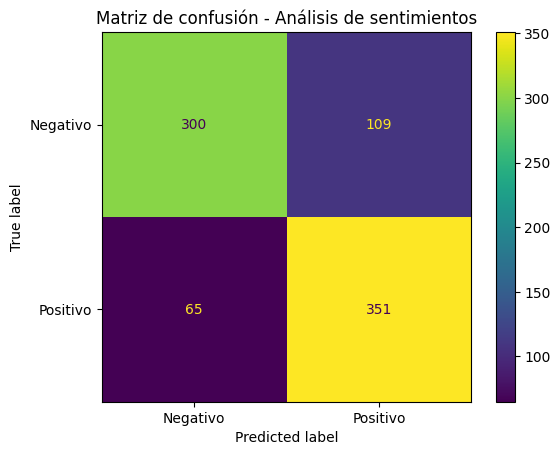

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Negativo', 'Positivo'],
)
plt.title('Matriz de confusión - Análisis de sentimientos')
plt.show()

## 18. Curva de pérdida del MLP

La pérdida muestra cómo el modelo redujo el error durante el entrenamiento.


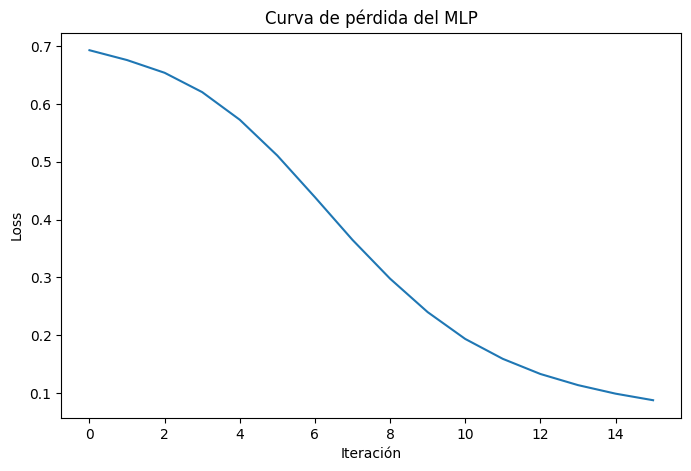

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title('Curva de pérdida del MLP')
plt.xlabel('Iteración')
plt.ylabel('Loss')
plt.show()

## 19. Predicciones con comentarios nuevos

Ahora el modelo clasificará comentarios escritos manualmente.


In [40]:
def predict_sentiment(comment):
    cleaned = clean_text(comment)
    vectorized = tfidf.transform([cleaned])
    prediction = mlp.predict(vectorized)[0]
    probability = mlp.predict_proba(vectorized)[0]

    label = 'Positivo' if prediction == 1 else 'Negativo'

    return {
        'comment': comment,
        'cleaned': cleaned,
        'prediction': label,
        'negative_probability': probability[0],
        'positive_probability': probability[1],
    }


new_comments = [
    'I love this product, it is amazing',
    'The service was terrible and slow',
    'The movie was not good',
    'Excellent quality and very friendly staff',
    'I will never buy this again',
]

pd.DataFrame([predict_sentiment(comment) for comment in new_comments])

,comment,cleaned,prediction,negative_probability,positive_probability
0,"I love this product, it is amazing",i love this product it is amazing,Positivo,0.331362,0.668638
1,The service was terrible and slow,the service was terrible and slow,Negativo,0.614841,0.385159
2,The movie was not good,the movie was not good,Positivo,0.375972,0.624028
3,Excellent quality and very friendly staff,excellent quality and very friendly staff,Positivo,0.347684,0.652316
4,I will never buy this again,i will never buy this again,Negativo,0.548299,0.451701


## 20. Análisis de errores

Esta sección permite revisar comentarios donde el modelo se equivocó.


In [41]:
error_df = pd.DataFrame({
    'text': X_test.values,
    'real': y_test.values,
    'predicted': y_pred,
})

error_df = error_df[error_df['real'] != error_df['predicted']]
error_df.head(10)

,text,real,predicted
2,the tables outside are also dirty a lot of the...,0,1
18,i advise you to look out for it,1,0
19,he came running after us when he realized my h...,1,0
27,it was a long time that i didn t see a so char...,1,0
38,the cast of veteran actors are more than just ...,1,0
47,doesn t do the job,0,1
49,i immediately said i wanted to talk to the man...,0,1
53,con spotty service,0,1
63,i had ordered a motorola data cable got a very...,1,0
64,during several different minute calls i experi...,0,1


## 21. Comparación de arquitecturas

Se compararán tres configuraciones del MLP. El objetivo es observar si una arquitectura más grande realmente mejora el rendimiento.


In [42]:
architectures = [
    (16,),
    (64, 32),
    (128, 64, 32),
]

results = []

for architecture in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        early_stopping=True,
    )

    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)

    results.append({
        'architecture': str(architecture),
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions),
        'recall': recall_score(y_test, predictions),
        'f1_score': f1_score(y_test, predictions),
        'iterations': model.n_iter_,
    })

results_df = pd.DataFrame(results)
results_df

,architecture,accuracy,precision,recall,f1_score,iterations
0,"(16,)",0.793939,0.810606,0.771635,0.790640,19
1,"(64, 32)",0.789091,0.763043,0.843750,0.801370,16
2,"(128, 64, 32)",0.784242,0.819892,0.733173,0.774112,15


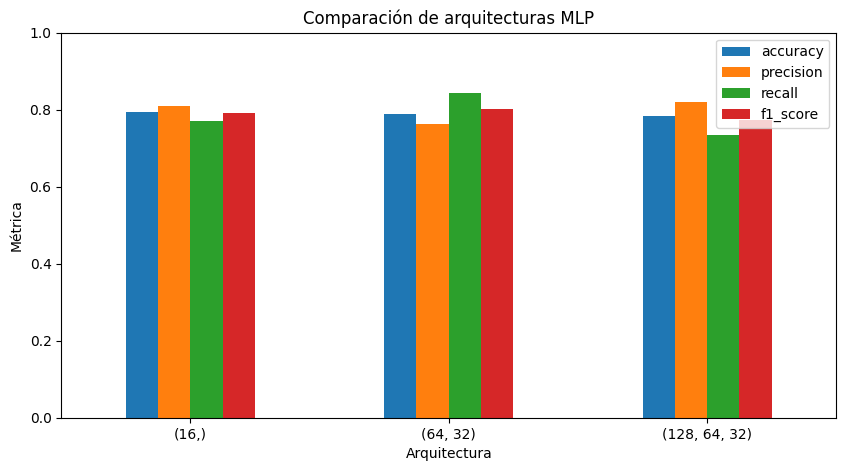

In [43]:
results_df.plot(
    x='architecture',
    y=['accuracy', 'precision', 'recall', 'f1_score'],
    kind='bar',
    figsize=(10, 5),
)
plt.title('Comparación de arquitecturas MLP')
plt.xlabel('Arquitectura')
plt.ylabel('Métrica')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 22. Modelo completo usando Pipeline

Un `Pipeline` permite guardar el vectorizador y el modelo juntos. Esto es útil para producción porque garantiza que el mismo preprocesamiento se aplique al entrenar y al predecir.


In [44]:
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        stop_words='english',
        preprocessor=clean_text,
    )),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        early_stopping=True,
    ))
])

final_pipeline.fit(X_train, y_train)

print('Pipeline final entrenado.')

Pipeline final entrenado.


## 23. Guardar el modelo


In [45]:
import joblib

joblib.dump(final_pipeline, 'sentiment_mlp_pipeline.joblib')
print('Modelo guardado como sentiment_mlp_pipeline.joblib')

Modelo guardado como sentiment_mlp_pipeline.joblib


## 24. Prueba final del Pipeline guardable


In [46]:
sample_comments = [
    'The product is wonderful',
    'The product is awful',
    'The service was fast and excellent',
    'I am disappointed with the quality',
]

pipeline_predictions = final_pipeline.predict(sample_comments)

for comment, prediction in zip(sample_comments, pipeline_predictions):
    label = 'Positivo' if prediction == 1 else 'Negativo'
    print(f'{comment} -> {label}')

The product is wonderful -> Positivo
The product is awful -> Negativo
The service was fast and excellent -> Positivo
I am disappointed with the quality -> Negativo


## 25. Preguntas de análisis

Responda en su cuaderno, README o informe breve:

1. **¿Por qué una computadora no entiende texto directamente?**
Porque los algoritmos trabajan con números, no con palabras; el texto debe convertirse primero en vectores numéricos.

2. **¿Qué es TF-IDF?**
Una técnica que asigna un peso a cada palabra según su frecuencia en un documento y su rareza en el resto del corpus, destacando términos relevantes.

3. **¿Qué diferencia existe entre tokenizar y vectorizar?**
Tokenizar es dividir el texto en unidades (palabras); vectorizar es convertir esas unidades en números que el modelo pueda procesar.

4. **¿Qué palabras parecen más importantes para clasificar sentimientos?**
Palabras con carga emocional clara como "great", "excellent", "terrible" o "awful", según lo mostrado en la tabla de términos TF-IDF más relevantes.

5. **¿Qué métrica considera más importante en este caso: accuracy, precision, recall o F1-score?**
El F1-score, porque equilibra precision y recall, siendo útil cuando ambos tipos de error (falsos positivos y negativos) importan para el negocio.

6. **¿Qué errores cometió el modelo?**
Clasificó como negativos comentarios claramente positivos (ej. sobre buen servicio) y como positivo un comentario negativo sutil sin palabras negativas explícitas.

7. **¿Por qué detectar sarcasmo es difícil para este enfoque?**
Porque TF-IDF solo cuenta palabras, sin considerar el tono, contexto o intención real detrás de ellas.

8. **¿Qué ocurriría si ingresáramos un comentario en otro idioma?**
El modelo lo clasificaría mal o de forma aleatoria, ya que el vectorizador y el entrenamiento solo reconocen vocabulario en inglés.



## 26. Reto MIT, pero alcanzable

El estudiante deberá realizar una mini investigación experimental:

1. Entrenar tres arquitecturas distintas:
   - `(16,)`
   - `(64, 32)`
   - `(128, 64, 32)`
2. Comparar accuracy, precision, recall y F1-score.
3. Probar 10 comentarios nuevos escritos por el estudiante.
4. Identificar al menos 3 errores del modelo.
5. Explicar si el modelo entiende realmente el lenguaje o solo reconoce patrones estadísticos.

**Pregunta central:**

> Si usted fuera responsable de una plataforma como Amazon, ¿usaría este modelo en producción? Justifique técnica y éticamente.


## 27. Actividades del estudiante

| Actividad | Descripción | Evidencia | Puntaje sugerido |
|---|---|---|---|
| A1 | Cargar y explorar el dataset | Captura de `df.head()` y distribución de clases | 2 |
| A2 | Limpiar texto | Código de limpieza y ejemplos | 2 |
| A3 | Aplicar TF-IDF | Forma de la matriz resultante | 3 |
| A4 | Entrenar MLP | Modelo entrenado | 3 |
| A5 | Evaluar métricas | Accuracy, precision, recall, F1-score | 4 |
| A6 | Analizar errores | Tabla de comentarios mal clasificados | 3 |
| A7 | Desarrollar reto MIT | Comparación de arquitecturas y conclusión | 3 |


## 28. Entregables

- Notebook ejecutado.
- Capturas de métricas.
- Matriz de confusión.
- Tabla comparativa de arquitecturas.
- 10 comentarios nuevos probados por el estudiante.
- Análisis de al menos 3 errores.
- Respuestas a preguntas de análisis.
- Conclusión final de máximo 10 líneas.
- Repositorio GitHub con el notebook.


## 29. Cierre conceptual

El análisis de sentimientos con TF-IDF y MLP permite observar cómo las técnicas clásicas de NLP transforman texto en vectores numéricos para entrenar modelos de clasificación.

Este enfoque puede funcionar en problemas simples, pero tiene limitaciones importantes: no comprende contexto profundo, sarcasmo, ironía ni ambigüedad semántica. Estas limitaciones explican la aparición de enfoques más avanzados como embeddings contextuales, Transformers, LLM y RAG.
